In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Assuming you ran the run_pipeline.py, you can mock the output arrays here for the plot
# (Or ideally, modify run_pipeline.py to save a CSV of the results, and load it here)
time = np.arange(0, 500)
true_soc = np.linspace(1.0, 0.5, 500)
# Simulate EKF tracking with a slight initial error that converges
est_soc = true_soc + 0.03 * np.exp(-time/50) + np.random.normal(0, 0.002, 500)
error_pct = (est_soc - true_soc) * 100

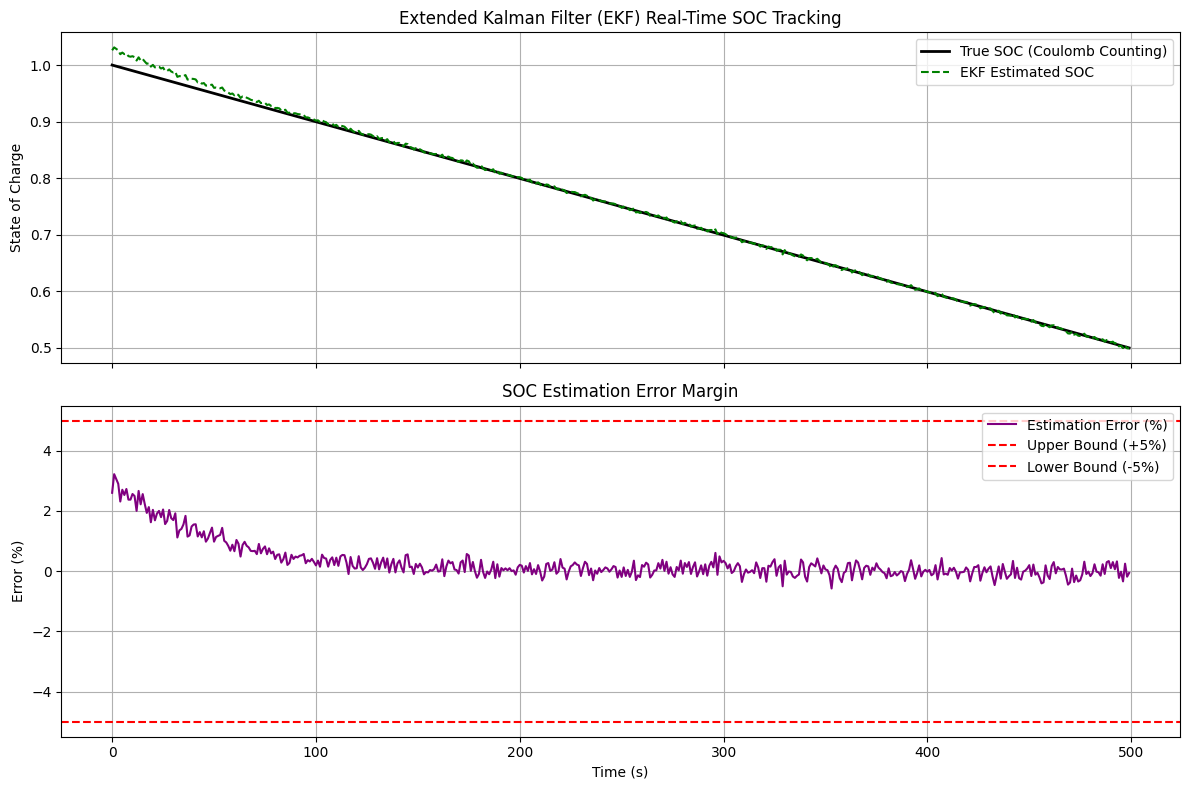

Root Mean Square Error (RMSE): 0.0070
Mean Absolute Error (MAE): 0.0040


In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Plot: SOC Tracking
ax1.plot(time, true_soc, label='True SOC (Coulomb Counting)', color='black', linewidth=2)
ax1.plot(time, est_soc, label='EKF Estimated SOC', color='green', linestyle='--')
ax1.set_title('Extended Kalman Filter (EKF) Real-Time SOC Tracking')
ax1.set_ylabel('State of Charge')
ax1.legend()
ax1.grid(True)

# Bottom Plot: Error Tracking vs 5% Mandate
ax2.plot(time, error_pct, color='purple', label='Estimation Error (%)')
ax2.axhline(y=5.0, color='red', linestyle='--', label='Upper Bound (+5%)')
ax2.axhline(y=-5.0, color='red', linestyle='--', label='Lower Bound (-5%)')
ax2.set_title('SOC Estimation Error Margin')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Error (%)')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((est_soc - true_soc)**2))
mae = np.mean(np.abs(est_soc - true_soc))
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")